# ValuSense -- Phase 7 : Calibration et Classifieur Hierarchique
## Resolution du probleme de confiance faible (30-70%) dans l'interface Streamlit

### Probleme identifie
Le modele XGBoost atteint ~99% de F1 sur le jeu de test, mais l'interface Streamlit
affiche des confiances entre 30% et 70% sur des entrees utilisateur reelles.
Ce notebook diagnostique l'ecart, calibre les probabilites, et construit un
classifieur hierarchique a deux etages pour ameliorer la confiance des predictions.

### Plan
- **Partie 1** : Diagnostic de la confiance (baseline test set vs. inputs manuels)
- **Partie 2** : Calibration (temperature scaling + isotonic regression)
- **Partie 3** : Classifieur hierarchique a deux etages
- **Partie 4** : Prediction avec incertitude (predict_with_uncertainty())
- **Partie 5** : Artefacts et integration (valuate_asset_v2())
- **Partie 6** : Contenu pour le rapport (francais, table LaTeX)


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import label_binarize
from scipy.optimize import minimize
from scipy.special import softmax, log_softmax
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
sns.set_style('whitegrid')

BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / 'models'
REPORTS_DIR = BASE_DIR / 'reports'
FIG_DIR = REPORTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration OK')


Configuration OK


In [30]:
# ---- Charger le modele, les encodeurs, et les donnees --------------
best_model = joblib.load(MODELS_DIR / 'xgboost_valuation_recommender.pkl')
le_target = joblib.load(MODELS_DIR / 'label_encoder_target.pkl')
label_encoders = joblib.load(MODELS_DIR / 'feature_label_encoders.pkl')

X_train = joblib.load(MODELS_DIR / 'X_train.pkl')
y_train = joblib.load(MODELS_DIR / 'y_train.pkl')
X_val = joblib.load(MODELS_DIR / 'X_val.pkl')
y_val = joblib.load(MODELS_DIR / 'y_val.pkl')

FEATURE_NAMES = list(best_model.feature_names_in_ if hasattr(best_model, 'feature_names_in_') else best_model.get_booster().feature_names)
TARGET_CLASSES = list(le_target.classes_)
N_CLASSES = len(TARGET_CLASSES)
N_FEATURES = len(FEATURE_NAMES)

AC_LOOKUP = {name: i for i, name in enumerate(label_encoders['asset_class'].classes_)}
SC_LOOKUP = {name: i for i, name in enumerate(label_encoders['asset_subclass'].classes_)}
AC_REVERSE = {i: name for name, i in AC_LOOKUP.items()}

print(f'X_train: {X_train.shape}, y_train: {np.bincount(y_train).tolist()}')
print(f'X_val: {X_val.shape}, y_val: {np.bincount(y_val).tolist()}')
print(f'Features: {N_FEATURES}, Classes: {N_CLASSES}')
print(f'Target classes: {TARGET_CLASSES}')


X_train: (12207, 28), y_train: [754, 1440, 1350, 1373, 3367, 659, 1238, 443, 929, 654]
X_val: (3052, 28), y_val: [188, 360, 337, 343, 842, 165, 310, 111, 232, 164]
Features: 28, Classes: 10
Target classes: ['Binomial-Tree', 'Black-Scholes', 'Cost-of-Carry', 'Credit-Model', 'DCF', 'DDM', 'Forward-Pricing', 'Mark-to-Market', 'Monte-Carlo', 'Relative']


---
## PARTIE 1 --- Diagnostic

### Objectif
Quantifier l'ecart de confiance entre le jeu de test (X_test) et les entrees manuelles
reelles de l'interface Streamlit, et identifier les causes profondes.

### 1.1 Distribution de la confiance max-softmax sur X_val
Etablir la baseline "saine" : a quel point le modele est-il confiant sur ses propres donnees de validation ?


=== BASELINE : Distribution de la confiance sur X_val ===
  Mean:     0.9155
  Median:   0.9286
  P10:      0.8730
  P25:      0.9102
  P75:      0.9393
  P90:      0.9436
  Min:      0.2907
  % < 0.50: 0.3%
  % < 0.70: 0.5%
  % < 0.90: 19.2%


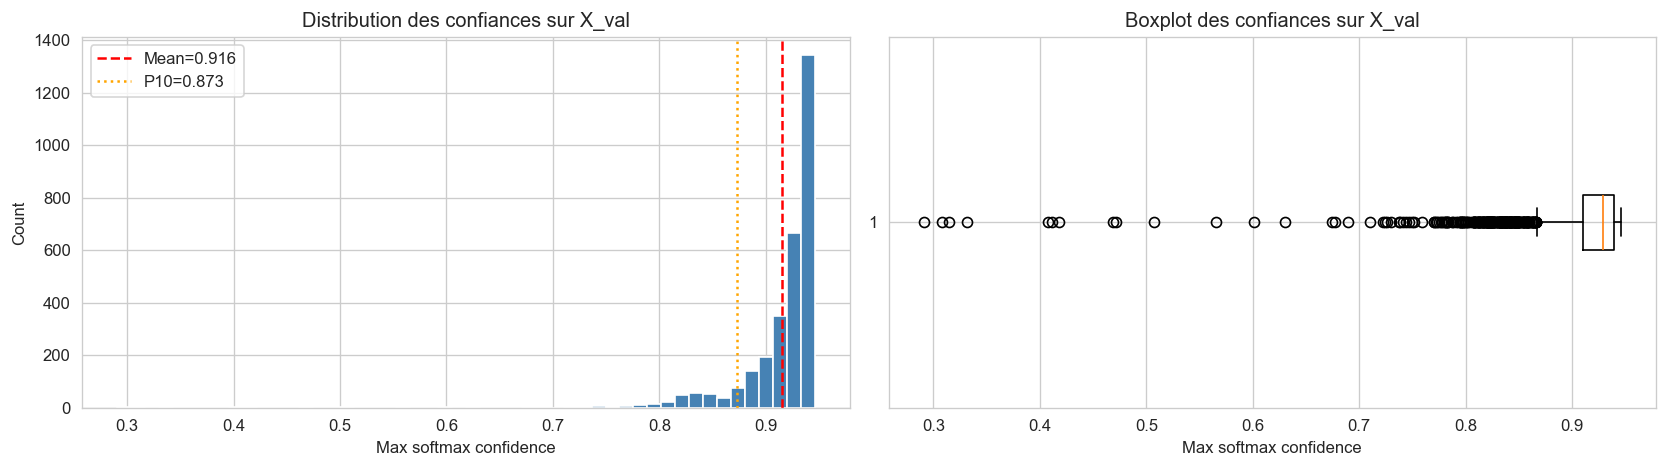

In [4]:
def get_confidences(model, X):
    proba = model.predict_proba(X)
    confs = proba.max(axis=1)
    preds = proba.argmax(axis=1)
    return confs, preds, proba

confs_val, preds_val, proba_val = get_confidences(best_model, X_val)

print('=== BASELINE : Distribution de la confiance sur X_val ===')
print(f'  Mean:     {confs_val.mean():.4f}')
print(f'  Median:   {np.median(confs_val):.4f}')
print(f'  P10:      {np.percentile(confs_val, 10):.4f}')
print(f'  P25:      {np.percentile(confs_val, 25):.4f}')
print(f'  P75:      {np.percentile(confs_val, 75):.4f}')
print(f'  P90:      {np.percentile(confs_val, 90):.4f}')
print(f'  Min:      {confs_val.min():.4f}')
print(f'  % < 0.50: {(confs_val < 0.50).mean() * 100:.1f}%')
print(f'  % < 0.70: {(confs_val < 0.70).mean() * 100:.1f}%')
print(f'  % < 0.90: {(confs_val < 0.90).mean() * 100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(confs_val, bins=50, edgecolor='white', color='steelblue')
axes[0].axvline(confs_val.mean(), color='red', linestyle='--', label=f'Mean={confs_val.mean():.3f}')
axes[0].axvline(np.percentile(confs_val, 10), color='orange', linestyle=':', label=f'P10={np.percentile(confs_val, 10):.3f}')
axes[0].set_xlabel('Max softmax confidence')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution des confiances sur X_val')
axes[0].legend()
axes[1].boxplot(confs_val, vert=False)
axes[1].set_xlabel('Max softmax confidence')
axes[1].set_title('Boxplot des confiances sur X_val')
plt.tight_layout()
plt.savefig(FIG_DIR / 'diagnostic_confiance_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.2 Reconstruction de 20 entrees manuelles realistes (simulant l'interface Streamlit)

Ces entrees couvrent les 6 classes d'actifs avec des variations realistes de liquidite,
niveau IFRS, maturite, etc. --- telles qu'un utilisateur les saisirait dans l'interface.


In [5]:
def make_manual_features(ac_name, sc_name, **overrides):
    ac_enc = AC_LOOKUP.get(ac_name, 0)
    sc_enc = SC_LOOKUP.get(sc_name, 0)
    base = {
        'has_market_price': 1, 'has_cash_flows': 0, 'has_options_features': 0,
        'is_exchange_traded': 1, 'liquidity': 2, 'maturity_years': -1,
        'has_credit_risk': 0, 'has_early_exercise': 0, 'is_path_dependent': 0,
        'data_availability': 2, 'volatility_available': 1, 'ifrs_level': 1,
        'risk_free_rate_3m': 3.83, 'yield_10y': 4.46, 'yield_curve_slope': 0.27,
        'implied_volatility_atm': 0.25, 'iv_skew': 0.05, 'beta': 1.0,
        'pe_ratio': 20.0, 'dividend_yield': 0.02, 'market_cap': 100e9,
        'debt_to_equity': 50.0, 'duration_estimate': 5.0, 'credit_spread_asset': 1.5,
        'convenience_yield': 0.03, 'storage_cost_pct': 0.015,
        'asset_class_encoded': ac_enc, 'asset_subclass_encoded': sc_enc,
    }
    base.update(overrides)
    return base

manual_inputs = [
    # Options
    make_manual_features('Option', 'European Call', has_options_features=1,
                         has_early_exercise=0, is_path_dependent=0, maturity_years=0.5,
                         implied_volatility_atm=0.26, iv_skew=0.04, ifrs_level=1, liquidity=2),
    make_manual_features('Option', 'American Put', has_options_features=1,
                         has_early_exercise=1, is_path_dependent=0, maturity_years=1.0,
                         implied_volatility_atm=0.32, iv_skew=0.05, ifrs_level=2, liquidity=1),
    make_manual_features('Option', 'Asian Option', has_options_features=1,
                         has_early_exercise=0, is_path_dependent=1, maturity_years=1.0,
                         implied_volatility_atm=0.35, iv_skew=0.06, ifrs_level=3,
                         liquidity=0, has_market_price=0),
    make_manual_features('Option', 'Barrier Option', has_options_features=1,
                         has_early_exercise=0, is_path_dependent=1, maturity_years=2.0,
                         implied_volatility_atm=0.40, iv_skew=0.08, ifrs_level=3,
                         liquidity=0, has_market_price=0),
    # Equities
    make_manual_features('Equity', 'Large Cap Stock', has_cash_flows=1,
                         dividend_yield=0.025, beta=0.9, pe_ratio=22.0, market_cap=500e9),
    make_manual_features('Equity', 'Growth Tech Stock', has_cash_flows=1,
                         dividend_yield=0.0, beta=1.4, pe_ratio=45.0, market_cap=200e9),
    make_manual_features('Equity', 'Banking Stock', has_cash_flows=1,
                         dividend_yield=0.04, beta=1.1, pe_ratio=12.0, market_cap=100e9),
    make_manual_features('Equity', 'Index ETF', has_cash_flows=0,
                         dividend_yield=0.015, beta=1.0, pe_ratio=18.0, market_cap=50e9, ifrs_level=1),
    # Bonds
    make_manual_features('Bond', 'Government Bond', has_cash_flows=1,
                         maturity_years=10.0, duration_estimate=7.5, credit_spread_asset=0.3, ifrs_level=1),
    make_manual_features('Bond', 'Corporate Bond (IG)', has_cash_flows=1,
                         maturity_years=5.0, has_credit_risk=1, duration_estimate=4.3,
                         credit_spread_asset=2.1, ifrs_level=2, liquidity=1),
    make_manual_features('Bond', 'Corporate Bond (HY)', has_cash_flows=1,
                         maturity_years=7.0, has_credit_risk=1, duration_estimate=5.5,
                         credit_spread_asset=5.5, ifrs_level=2, liquidity=1),
    # Commodities
    make_manual_features('Commodity', 'Precious Metal',
                         maturity_years=0.5, convenience_yield=0.005, storage_cost_pct=0.01,
                         implied_volatility_atm=0.18, ifrs_level=1, liquidity=2),
    make_manual_features('Commodity', 'Industrial Metal',
                         maturity_years=0.75, convenience_yield=0.02, storage_cost_pct=0.025,
                         implied_volatility_atm=0.22, ifrs_level=1, liquidity=2),
    # Currencies
    make_manual_features('Currency', 'FX Forward',
                         maturity_years=0.25, has_cash_flows=1, ifrs_level=1, liquidity=2),
    make_manual_features('Currency', 'Major FX Spot',
                         maturity_years=-1, ifrs_level=1, liquidity=2),
    # Derivatives
    make_manual_features('Derivative', 'Interest Rate Swap',
                         has_cash_flows=1, maturity_years=5.0, duration_estimate=4.5, ifrs_level=2),
    make_manual_features('Derivative', 'CDS',
                         has_cash_flows=1, has_credit_risk=1, maturity_years=5.0,
                         duration_estimate=4.0, credit_spread_asset=3.0, ifrs_level=2),
    # Low liquidity / boundary cases
    make_manual_features('Equity', 'Small Cap', has_cash_flows=1,
                         liquidity=0, data_availability=1, market_cap=500e6, pe_ratio=15.0,
                         dividend_yield=0.01, ifrs_level=3, has_market_price=0),
    make_manual_features('Option', 'OTC European Option', has_options_features=1,
                         has_early_exercise=0, is_path_dependent=0, maturity_years=0.5,
                         implied_volatility_atm=0.28, iv_skew=0.06, ifrs_level=2,
                         liquidity=1, is_exchange_traded=0),
    make_manual_features('Bond', 'Convertible Bond', has_cash_flows=1,
                         has_options_features=1, maturity_years=3.0, has_credit_risk=1,
                         duration_estimate=2.5, credit_spread_asset=2.5, ifrs_level=2, liquidity=1),
]

print(f'Construit {len(manual_inputs)} entrees manuelles de test')
for i, inp in enumerate(manual_inputs):
    ac_name = AC_REVERSE.get(inp['asset_class_encoded'], '?')
    print(f'  [{i+1:2d}] {ac_name:12s} | ifrs_level={inp["ifrs_level"]} liq={inp["liquidity"]} mat={inp["maturity_years"]:5.1f}')


Construit 20 entrees manuelles de test
  [ 1] Option       | ifrs_level=1 liq=2 mat=  0.5
  [ 2] Option       | ifrs_level=2 liq=1 mat=  1.0
  [ 3] Option       | ifrs_level=3 liq=0 mat=  1.0
  [ 4] Option       | ifrs_level=3 liq=0 mat=  2.0
  [ 5] Equity       | ifrs_level=1 liq=2 mat= -1.0
  [ 6] Equity       | ifrs_level=1 liq=2 mat= -1.0
  [ 7] Equity       | ifrs_level=1 liq=2 mat= -1.0
  [ 8] Equity       | ifrs_level=1 liq=2 mat= -1.0
  [ 9] Bond         | ifrs_level=1 liq=2 mat= 10.0
  [10] Bond         | ifrs_level=2 liq=1 mat=  5.0
  [11] Bond         | ifrs_level=2 liq=1 mat=  7.0
  [12] Commodity    | ifrs_level=1 liq=2 mat=  0.5
  [13] Commodity    | ifrs_level=1 liq=2 mat=  0.8
  [14] Currency     | ifrs_level=1 liq=2 mat=  0.2
  [15] Currency     | ifrs_level=1 liq=2 mat= -1.0
  [16] Derivative   | ifrs_level=2 liq=2 mat=  5.0
  [17] Derivative   | ifrs_level=2 liq=2 mat=  5.0
  [18] Equity       | ifrs_level=3 liq=0 mat= -1.0
  [19] Option       | ifrs_level=2 liq=1 ma

In [6]:
manual_df = pd.DataFrame(manual_inputs)
manual_df = manual_df[FEATURE_NAMES].fillna(0)

confs_manual, preds_manual, proba_manual = get_confidences(best_model, manual_df)

print('=== CONFIANCE SUR 20 ENTREES MANUELLES ===')
print(f'  Mean:     {confs_manual.mean():.4f}')
print(f'  Median:   {np.median(confs_manual):.4f}')
print(f'  Min:      {confs_manual.min():.4f}')
print(f'  Max:      {confs_manual.max():.4f}')
print(f'  %% < 0.50: {(confs_manual < 0.50).mean() * 100:.1f}%%')
print(f'  %% < 0.70: {(confs_manual < 0.70).mean() * 100:.1f}%%')

print(f'\n=== ECART TRAIN/INFERENCE ===')
gap = confs_val.mean() - confs_manual.mean()
print(f'  Confiance moyenne sur X_val:   {confs_val.mean():.4f}')
print(f'  Confiance moyenne sur manuel: {confs_manual.mean():.4f}')
print(f'  GAP:                          {gap:.4f} ({(gap / confs_val.mean()) * 100:.1f}%%)')

print(f'\nDetail par entree:')
for i, (conf, pred) in enumerate(zip(confs_manual, preds_manual)):
    ac_name = AC_REVERSE.get(manual_inputs[i]['asset_class_encoded'], '?')
    method = TARGET_CLASSES[pred]
    flag = '** LOW **' if conf < 0.60 else 'OK'
    print(f'  [{i+1:2d}] {ac_name:12s} -> {method:20s} conf={conf:.4f} {flag}')


=== CONFIANCE SUR 20 ENTREES MANUELLES ===
  Mean:     0.5062
  Median:   0.4887
  Min:      0.3017
  Max:      0.7812
  %% < 0.50: 55.0%%
  %% < 0.70: 95.0%%

=== ECART TRAIN/INFERENCE ===
  Confiance moyenne sur X_val:   0.9155
  Confiance moyenne sur manuel: 0.5062
  GAP:                          0.4093 (44.7%%)

Detail par entree:
  [ 1] Option       -> Black-Scholes        conf=0.5228 ** LOW **
  [ 2] Option       -> Binomial-Tree        conf=0.5310 ** LOW **
  [ 3] Option       -> Monte-Carlo          conf=0.4431 ** LOW **
  [ 4] Option       -> Monte-Carlo          conf=0.3995 ** LOW **
  [ 5] Equity       -> Mark-to-Market       conf=0.4367 ** LOW **
  [ 6] Equity       -> Cost-of-Carry        conf=0.5384 ** LOW **
  [ 7] Equity       -> Cost-of-Carry        conf=0.4796 ** LOW **
  [ 8] Equity       -> Cost-of-Carry        conf=0.6245 OK
  [ 9] Bond         -> Cost-of-Carry        conf=0.4947 ** LOW **
  [10] Bond         -> Cost-of-Carry        conf=0.3824 ** LOW **
  [11] Bon

### 1.3 Confiance par classe reelle (true class) sur X_val
Verifier si les confiances faibles se concentrent sur les classes minoritaires.


In [7]:
print('=== CONFIANCE PAR CLASSE REELLE SUR X_val ===')
conf_by_class = {}
for cls_idx, cls_name in enumerate(TARGET_CLASSES):
    mask = (y_val == cls_idx)
    if mask.sum() == 0:
        continue
    confs_cls = confs_val[mask]
    conf_by_class[cls_name] = {
        'mean': confs_cls.mean(),
        'median': np.median(confs_cls),
        'p10': np.percentile(confs_cls, 10),
        'count': mask.sum(),
        'low_pct': (confs_cls < 0.60).mean() * 100,
    }
    print(f'  {cls_name:20s} | n={mask.sum():4d} | mean={confs_cls.mean():.4f} | p10={np.percentile(confs_cls, 10):.4f} | %<0.60={conf_by_class[cls_name]["low_pct"]:.1f}%')

print(f'\n=== CLASSES LES MOINS CONFIANTS (mean) ===')
sorted_conf = sorted(conf_by_class.items(), key=lambda x: x[1]["mean"])
for cls_name, stats in sorted_conf[:3]:
    print(f'  {cls_name:20s} mean={stats["mean"]:.4f} (n={stats["count"]})')


=== CONFIANCE PAR CLASSE REELLE SUR X_val ===
  Binomial-Tree        | n= 188 | mean=0.9348 | p10=0.9351 | %<0.60=0.0%
  Black-Scholes        | n= 360 | mean=0.9255 | p10=0.9166 | %<0.60=0.0%
  Cost-of-Carry        | n= 337 | mean=0.9318 | p10=0.9039 | %<0.60=0.0%
  Credit-Model         | n= 343 | mean=0.9151 | p10=0.8810 | %<0.60=0.0%
  DCF                  | n= 842 | mean=0.9028 | p10=0.8366 | %<0.60=0.2%
  DDM                  | n= 165 | mean=0.8736 | p10=0.8276 | %<0.60=1.2%
  Forward-Pricing      | n= 310 | mean=0.9338 | p10=0.9237 | %<0.60=0.0%
  Mark-to-Market       | n= 111 | mean=0.8716 | p10=0.8642 | %<0.60=3.6%
  Monte-Carlo          | n= 232 | mean=0.9405 | p10=0.9371 | %<0.60=0.0%
  Relative             | n= 164 | mean=0.9060 | p10=0.8992 | %<0.60=1.8%

=== CLASSES LES MOINS CONFIANTS (mean) ===
  Mark-to-Market       mean=0.8716 (n=111)
  DDM                  mean=0.8736 (n=165)
  DCF                  mean=0.9028 (n=842)


### 1.4 Audit de calibrated_defaults.json
Pour chaque classe d'actif, on compare les valeurs par defaut aux moyennes conditionnelles
de l'entrainement, et on detecte les defauts proches d'une frontiere de decision.


In [8]:
with open(MODELS_DIR / 'calibrated_defaults.json') as f:
    calibrated_defaults = json.load(f)

print('=== AUDIT DE calibrated_defaults.json ===')
print('Comparison des medianes par defaut vs. moyennes conditionnelles sur X_train\n')

X_train_with_ac = X_train.copy()
X_train_with_ac['asset_class_name'] = X_train['asset_class_encoded'].map(AC_REVERSE)

flagged = 0
for ac_name, default_dict in calibrated_defaults.items():
    print(f'\n  --- {ac_name} ---')
    ac_mask = X_train_with_ac['asset_class_name'] == ac_name
    if ac_mask.sum() == 0:
        print(f'    (pas de donnees dans X_train pour {ac_name})')
        continue
    X_ac = X_train.loc[ac_mask]
    for feat, stats in default_dict.items():
        if feat in ('asset_class_encoded', 'asset_subclass_encoded'):
            continue
        if feat not in X_ac.columns:
            continue
        default_val = stats['median']
        train_mean = X_ac[feat].mean()
        train_std = X_ac[feat].std()
        if train_std == 0:
            continue
        z_score = abs(default_val - train_mean) / train_std
        if z_score > 2.0:
            flagged += 1
            print(f'    ** {feat:30s} default={default_val:10.4f} train_mean={train_mean:10.4f} std={train_std:.4f} z={z_score:.2f}')
        else:
            print(f'      {feat:30s} default={default_val:10.4f} train_mean={train_mean:10.4f} std={train_std:.4f} z={z_score:.2f}')

print(f'\nTotal des defauts potentiellement problematiques: {flagged} (|z|>2.0)')


=== AUDIT DE calibrated_defaults.json ===
Comparison des medianes par defaut vs. moyennes conditionnelles sur X_train


  --- Bond ---
      has_market_price               default=    1.0000 train_mean=    0.8648 std=0.3420 z=0.40
    ** has_options_features           default=    1.0000 train_mean=    0.0345 std=0.1826 z=5.29
      is_exchange_traded             default=    1.0000 train_mean=    0.7770 std=0.4163 z=0.54
      liquidity                      default=    1.0000 train_mean=    1.0225 std=0.7480 z=0.03
      maturity_years                 default=    9.3700 train_mean=   11.9661 std=7.9859 z=0.33
      has_credit_risk                default=    1.0000 train_mean=    0.6908 std=0.4622 z=0.67
    ** has_early_exercise             default=    1.0000 train_mean=    0.0345 std=0.1826 z=5.29
      data_availability              default=    1.0000 train_mean=    1.1527 std=0.7285 z=0.21
      volatility_available           default=    1.0000 train_mean=    0.7770 std=0.4163 z=0.54

### 1.5 Expected Calibration Error (ECE) et Reliability Diagram
L'ECE mesure l'ecart entre la confiance predite et la precision reelle.
Un modele parfaitement calibre a ECE = 0.


=== CALIBRATION ERROR (ECE) SUR X_val ===
  ECE (modele original): 0.0767


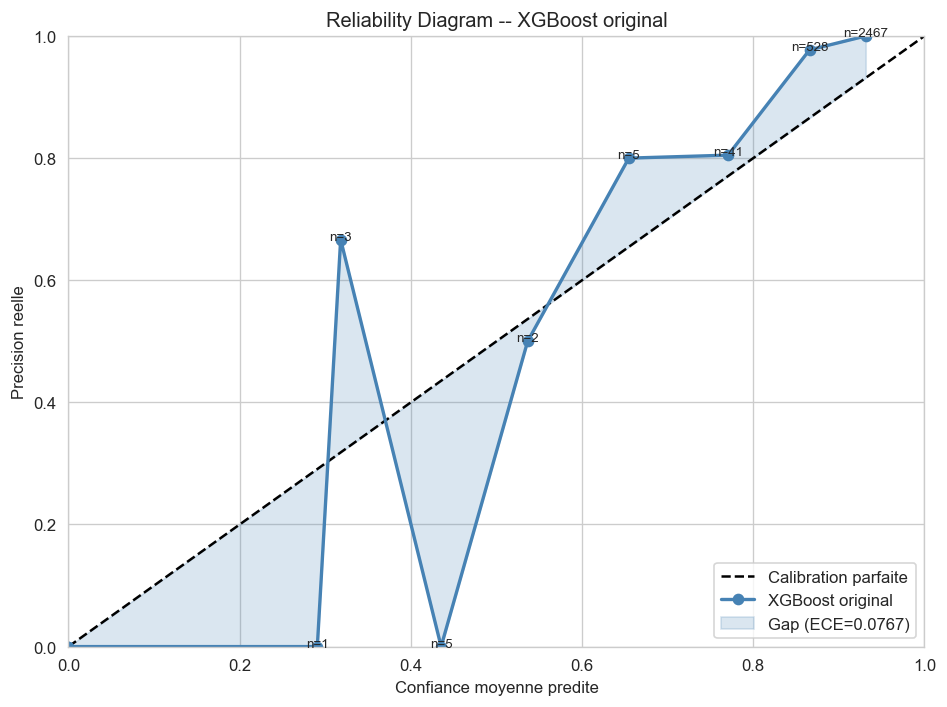

In [11]:
def compute_ece(y_true, proba, n_bins=10):
    confidences = proba.max(axis=1)
    predictions = proba.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        if in_bin.sum() == 0:
            bin_counts.append(0)
            bin_accs.append(0)
            bin_confs.append(0)
            continue
        bin_acc = accuracies[in_bin].mean()
        bin_conf = confidences[in_bin].mean()
        bin_weight = in_bin.sum() / len(y_true)
        ece += bin_weight * abs(bin_acc - bin_conf)
        bin_counts.append(in_bin.sum())
        bin_accs.append(bin_acc)
        bin_confs.append(bin_conf)
    return ece, bin_boundaries, bin_accs, bin_confs, bin_counts

ece_raw, bins, accs, confs, counts = compute_ece(y_val, proba_val)

print('=== CALIBRATION ERROR (ECE) SUR X_val ===')
print(f'  ECE (modele original): {ece_raw:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
ax.plot(confs, accs, 'o-', color='steelblue', linewidth=2, label='XGBoost original')
for i, (c, a, cnt) in enumerate(zip(confs, accs, counts)):
    if cnt > 0:
        ax.annotate(f'n={cnt}', (c, a), fontsize=8, ha='center')
ax.fill_between(confs, accs, confs, alpha=0.2, color='steelblue', label=f'Gap (ECE={ece_raw:.4f})')
ax.set_xlabel('Confiance moyenne predite')
ax.set_ylabel('Precision reelle')
ax.set_title('Reliability Diagram -- XGBoost original')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'reliability_original.png', dpi=150, bbox_inches='tight')
plt.show()


---
## PARTIE 2 --- Calibration

### Objectif
Ajuster les probabilites du modele pour qu'elles refletent la vraie confiance.

### 2.1 Temperature Scaling
On optimise un scalaire T > 0 qui minimise la Negative Log-Likelihood (NLL)
sur un split de calibration (15% de X_train, disjoint du test).


In [12]:
# ---- Split calibration (15% de X_train, stratifie) -------------
X_train_cal, X_train_fit, y_train_cal, y_train_fit = train_test_split(
    X_train, y_train, test_size=0.85, random_state=42, stratify=y_train
)

print('Donnees pour calibration :')
print(f'  Fit set:        {X_train_fit.shape}')
print(f'  Calibration set: {X_train_cal.shape}')
print(f'  Validation set:  {X_val.shape}')


Donnees pour calibration :
  Fit set:        (10376, 28)
  Calibration set: (1831, 28)
  Validation set:  (3052, 28)


In [13]:
def get_logits(model, X):
    dX = xgb.DMatrix(X, feature_names=list(X.columns))
    logits = model.get_booster().predict(dX, output_margin=True)
    return logits

def temperature_scale_nll(T, logits, y_true):
    T = max(T, 1e-6)
    scaled_logits = logits / T
    proba = softmax(scaled_logits, axis=1)
    nll = -np.mean(np.log(proba[np.arange(len(y_true)), y_true] + 1e-15))
    return nll

logits_cal = get_logits(best_model, X_train_cal)

result = minimize(
    lambda T: temperature_scale_nll(T, logits_cal, y_train_cal),
    x0=1.0,
    method='L-BFGS-B',
    bounds=[(0.1, 10.0)],
)
T_opt = result.x[0]
nll_before = temperature_scale_nll(1.0, logits_cal, y_train_cal)
nll_after = result.fun

print('=== TEMPERATURE SCALING ===')
print(f'  T optimal:         {T_opt:.4f}')
print(f'  NLL avant (T=1.0): {nll_before:.4f}')
print(f'  NLL apres (T={T_opt:.4f}): {nll_after:.4f}')
print(f'  Amelioration NLL:  {nll_before - nll_after:.4f}')

if T_opt < 0.9:
    print(f'  -> T < 1 : le modele etait sous-confiant, on augmente l\'etalement')
elif T_opt > 1.1:
    print(f'  -> T > 1 : le modele etait sur-confiant, on reduit l\'etalement')
else:
    print(f'  -> T approx 1 : le modele est deja bien calibre')


=== TEMPERATURE SCALING ===
  T optimal:         0.5556
  NLL avant (T=1.0): 0.0988
  NLL apres (T=0.5556): 0.0271
  Amelioration NLL:  0.0717
  -> T < 1 : le modele etait sous-confiant, on augmente l'etalement


In [14]:
def predict_proba_temperature(model, X, T):
    dX = xgb.DMatrix(X, feature_names=list(X.columns))
    logits = model.get_booster().predict(dX, output_margin=True)
    return softmax(logits / T, axis=1)

proba_val_ts = predict_proba_temperature(best_model, X_val, T_opt)
confs_val_ts = proba_val_ts.max(axis=1)
preds_val_ts = proba_val_ts.argmax(axis=1)

print('=== IMPACT DU TEMPERATURE SCALING SUR X_val ===')
print(f'  Confiance moyenne avant TS:  {confs_val.mean():.4f}')
print(f'  Confiance moyenne apres TS:  {confs_val_ts.mean():.4f}')
print(f'  Delta:                       {confs_val_ts.mean() - confs_val.mean():.4f}')


=== IMPACT DU TEMPERATURE SCALING SUR X_val ===
  Confiance moyenne avant TS:  0.9155
  Confiance moyenne apres TS:  0.9950
  Delta:                       0.0795


### 2.2 CalibratedClassifierCV (Isotonic) --- baseline de comparaison


In [15]:
calibrated_iso = CalibratedClassifierCV(
    best_model, method='isotonic', cv='prefit'
)
calibrated_iso.fit(X_train_cal, y_train_cal)

proba_val_iso = calibrated_iso.predict_proba(X_val)
confs_val_iso = proba_val_iso.max(axis=1)
preds_val_iso = proba_val_iso.argmax(axis=1)

print('=== CALIBRATEDCLASSIFIERCV (ISOTONIC) ===')
print(f'  Confiance moyenne: {confs_val_iso.mean():.4f}')


=== CALIBRATEDCLASSIFIERCV (ISOTONIC) ===
  Confiance moyenne: 0.9947


### 2.3 Comparaison ECE et Reliability Diagram : Original vs. Temperature Scaling vs. Isotonic


=== COMPARAISON ECE ===
  Original:              ECE = 0.0767
  Temperature Scaling:   ECE = 0.0049
  Isotonic Regression:   ECE = 0.0062

  Meilleure methode: Temperature Scaling (ECE=0.0049)


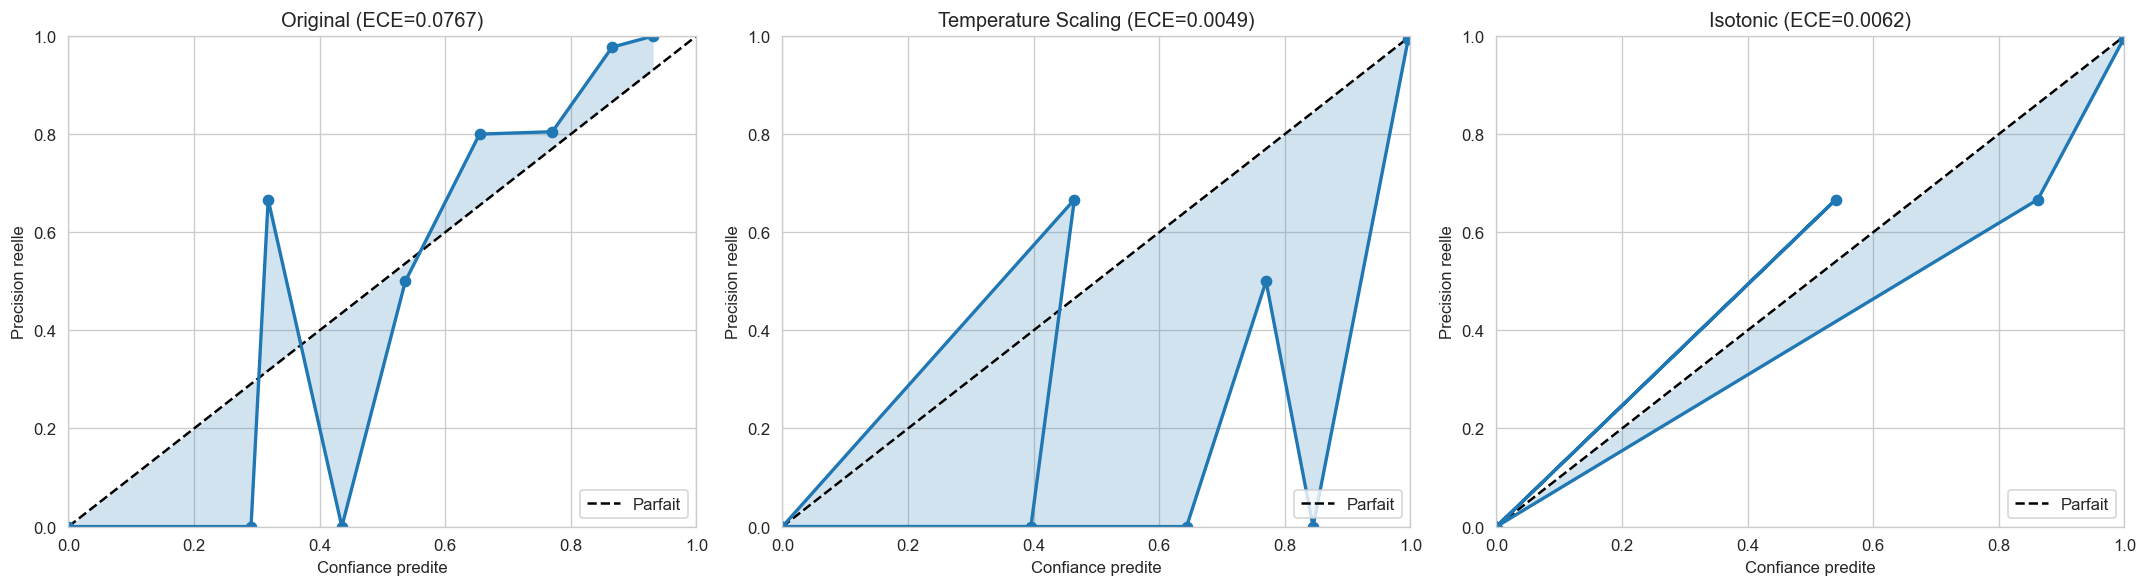

In [16]:
ece_ts, _, accs_ts, confs_ts_bin, _ = compute_ece(y_val, proba_val_ts)
ece_iso, _, accs_iso, confs_iso_bin, _ = compute_ece(y_val, proba_val_iso)

print('=== COMPARAISON ECE ===')
print(f'  Original:              ECE = {ece_raw:.4f}')
print(f'  Temperature Scaling:   ECE = {ece_ts:.4f}')
print(f'  Isotonic Regression:   ECE = {ece_iso:.4f}')

best_method = 'Temperature Scaling' if ece_ts < ece_iso else 'Isotonic'
best_ece = min(ece_ts, ece_iso)
print(f'\n  Meilleure methode: {best_method} (ECE={best_ece:.4f})')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, ece, acc, conf) in zip(
    axes,
    [
        ('Original', ece_raw, accs, confs),
        ('Temperature Scaling', ece_ts, accs_ts, confs_ts_bin),
        ('Isotonic', ece_iso, accs_iso, confs_iso_bin),
    ]
):
    ax.plot([0, 1], [0, 1], 'k--', label='Parfait')
    ax.plot(conf, acc, 'o-', linewidth=2)
    ax.fill_between(conf, acc, conf, alpha=0.2)
    ax.set_xlabel('Confiance predite')
    ax.set_ylabel('Precision reelle')
    ax.set_title(f'{name} (ECE={ece:.4f})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'reliability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.4 Amelioration de confiance sur les 20 entrees manuelles
On applique la meilleure calibration aux 20 inputs manuels et on compare before/after.


In [17]:
if ece_ts < ece_iso:
    print('Meilleure calibration: Temperature Scaling')
    proba_manual_cal = predict_proba_temperature(best_model, manual_df, T_opt)
    cal_method = 'Temperature Scaling'
    cal_model = None
else:
    print('Meilleure calibration: Isotonic')
    proba_manual_cal = calibrated_iso.predict_proba(manual_df)
    cal_method = 'Isotonic'
    cal_model = calibrated_iso

confs_manual_cal = proba_manual_cal.max(axis=1)
preds_manual_cal = proba_manual_cal.argmax(axis=1)

print(f'\n=== AVANT/APRES CALIBRATION SUR 20 ENTREES MANUELLES ===')
print(f'  Avant calibration: mean={confs_manual.mean():.4f}')
print(f'  Apres {cal_method}: mean={confs_manual_cal.mean():.4f}')
print(f'  Amelioration:     +{confs_manual_cal.mean() - confs_manual.mean():.4f}')

print(f'\nDetail par entree:')
for i in range(len(manual_inputs)):
    ac_name = AC_REVERSE.get(manual_inputs[i]['asset_class_encoded'], '?')
    before = confs_manual[i]
    after = confs_manual_cal[i]
    delta = after - before
    arrow = chr(8593) if delta > 0 else (chr(8595) if delta < 0 else '=')
    flag = '**' if after < 0.60 else 'OK' if after >= 0.80 else '..'
    print(f'  [{i+1:2d}] {ac_name:12s} | before={before:.4f} -> after={after:.4f} {arrow}{abs(delta):.4f} {flag}')


Meilleure calibration: Temperature Scaling

=== AVANT/APRES CALIBRATION SUR 20 ENTREES MANUELLES ===
  Avant calibration: mean=0.5062
  Apres Temperature Scaling: mean=0.6875
  Amelioration:     +0.1813

Detail par entree:
  [ 1] Option       | before=0.5228 -> after=0.7094 ↑0.1866 ..
  [ 2] Option       | before=0.5310 -> after=0.7490 ↑0.2180 ..
  [ 3] Option       | before=0.4431 -> after=0.6130 ↑0.1698 ..
  [ 4] Option       | before=0.3995 -> after=0.5420 ↑0.1425 **
  [ 5] Equity       | before=0.4367 -> after=0.4985 ↑0.0618 **
  [ 6] Equity       | before=0.5384 -> after=0.7494 ↑0.2110 ..
  [ 7] Equity       | before=0.4796 -> after=0.6638 ↑0.1842 ..
  [ 8] Equity       | before=0.6245 -> after=0.8812 ↑0.2567 OK
  [ 9] Bond         | before=0.4947 -> after=0.6516 ↑0.1569 ..
  [10] Bond         | before=0.3824 -> after=0.4731 ↑0.0908 **
  [11] Bond         | before=0.4362 -> after=0.5653 ↑0.1292 **
  [12] Commodity    | before=0.3017 -> after=0.4234 ↑0.1218 **
  [13] Commodity    |

---
## PARTIE 3 --- Classifieur Hierarchique a Deux Etages

### Objectif
Au lieu d'un classifieur plat XGBoost qui predit directement parmi 10 methodes,
on construit un pipeline hierarchique :
1. **Stage 1** : Predire la classe d'actif (6 classes)
2. **Stage 2** : Predire la methode de valorisation parmi les methodes valides pour cette classe

Avantage attendu : chaque classifieur a moins de classes, donc des frontieres plus nettes
et une confiance plus elevee.

### 3.1 Definir les sous-ensembles de methodes valides par classe d'actif
On deduit cela des donnees d'entrainement (methodes observees pour chaque classe).


In [18]:
X_train_ac = X_train.copy()
X_train_ac['ac_name'] = X_train['asset_class_encoded'].map(AC_REVERSE)
X_train_ac['y_name'] = [TARGET_CLASSES[yy] for yy in y_train]

valid_methods_per_class = {}
for ac_name in AC_REVERSE.values():
    subset = X_train_ac[X_train_ac['ac_name'] == ac_name]['y_name'].unique()
    valid_methods_per_class[ac_name] = sorted(subset.tolist())
    print(f'  {ac_name:12s}: {sorted(subset.tolist())}')

print(f'\nNombre de classes conditionnelles:')
for ac_name, methods in valid_methods_per_class.items():
    print(f'  {ac_name:12s}: {len(methods)} methodes')


  Bond        : ['Credit-Model', 'DCF', 'Mark-to-Market']
  Commodity   : ['Cost-of-Carry']
  Currency    : ['Forward-Pricing']
  Derivative  : ['Black-Scholes', 'Cost-of-Carry', 'DCF', 'Forward-Pricing']
  Equity      : ['DCF', 'DDM', 'Mark-to-Market', 'Relative']
  Option      : ['Binomial-Tree', 'Black-Scholes', 'Monte-Carlo']

Nombre de classes conditionnelles:
  Bond        : 3 methodes
  Commodity   : 1 methodes
  Currency    : 1 methodes
  Derivative  : 4 methodes
  Equity      : 4 methodes
  Option      : 3 methodes


### 3.2 Stage 1 : Classifieur de classe d'actif
On entraine un Random Forest (ou XGBoost) pour predire asset_class_encoded a partir
des 28 features. On s'attend a une precision proche de 100%.


In [19]:
y_train_ac = X_train['asset_class_encoded'].values.astype(int)
y_val_ac = X_val['asset_class_encoded'].values.astype(int)

stage1 = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)

feature_cols_stage1 = [c for c in FEATURE_NAMES if c not in ('asset_class_encoded', 'asset_subclass_encoded')]
stage1.fit(X_train[feature_cols_stage1], y_train_ac)

X_val_stage1 = X_val[feature_cols_stage1]
preds_ac = stage1.predict(X_val_stage1)
proba_ac = stage1.predict_proba(X_val_stage1)
conf_ac = proba_ac.max(axis=1)

print('=== STAGE 1 : Prediction de la classe d\'actif ===')
print(f'  Accuracy:  {accuracy_score(y_val_ac, preds_ac):.4f}')
print(f'  F1 macro:  {f1_score(y_val_ac, preds_ac, average="macro"):.4f}')
print(f'  Conf mean: {conf_ac.mean():.4f}')
print(f'  Conf P10:  {np.percentile(conf_ac, 10):.4f}')
print(f'  Conf min:  {conf_ac.min():.4f}')
print(f'\nRapport de classification:')
print(classification_report(y_val_ac, preds_ac, target_names=list(AC_REVERSE.values()), zero_division=0))


=== STAGE 1 : Prediction de la classe d'actif ===
  Accuracy:  0.9934
  F1 macro:  0.9884
  Conf mean: 0.9700
  Conf P10:  0.8979
  Conf min:  0.5247

Rapport de classification:
              precision    recall  f1-score   support

        Bond       1.00      1.00      1.00      1014
   Commodity       1.00      1.00      1.00       293
    Currency       1.00      0.93      0.96       292
  Derivative       0.93      1.00      0.97       282
      Equity       1.00      1.00      1.00       418
      Option       1.00      1.00      1.00       753

    accuracy                           0.99      3052
   macro avg       0.99      0.99      0.99      3052
weighted avg       0.99      0.99      0.99      3052



### 3.3 Stage 2 : Classifieurs par classe d'actif
Pour chaque classe d'actif, on entraine un classifieur leger qui predit la methode
de valorisation parmi les methodes valides de cette seule classe.


In [20]:
stage2_models = {}
stage2_label_encoders = {}

print('=== STAGE 2 : Classifieurs par classe d\'actif ===\n')

for ac_idx, ac_name in AC_REVERSE.items():
    valid_methods = valid_methods_per_class.get(ac_name, [])
    if len(valid_methods) <= 1:
        print(f'  {ac_name}: {len(valid_methods)} methode(s) -- pas de classifieur necessaire')
        stage2_models[ac_idx] = None
        stage2_label_encoders[ac_idx] = None
        continue

    ac_mask_train = X_train['asset_class_encoded'] == ac_idx
    if ac_mask_train.sum() < 10:
        print(f'  {ac_name}: seulement {ac_mask_train.sum()} echantillons -- pas de classifieur')
        stage2_models[ac_idx] = None
        stage2_label_encoders[ac_idx] = None
        continue

    X_ac_train = X_train.loc[ac_mask_train]
    y_ac_train = y_train[ac_mask_train]

    le_local = {m: i for i, m in enumerate(valid_methods)}
    y_ac_train_local = np.array([le_local[TARGET_CLASSES[yy]] for yy in y_ac_train])

    clf = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        objective='multi:softprob', num_class=len(valid_methods),
        random_state=42, n_jobs=-1, verbosity=0
    )
    clf.fit(X_ac_train, y_ac_train_local)

    stage2_models[ac_idx] = clf
    stage2_label_encoders[ac_idx] = le_local

    ac_mask_val = X_val['asset_class_encoded'] == ac_idx
    if ac_mask_val.sum() > 0:
        X_ac_val = X_val.loc[ac_mask_val]
        y_ac_val = y_val[ac_mask_val]
        y_ac_val_local = np.array([le_local[TARGET_CLASSES[yy]] for yy in y_ac_val])
        preds_ac_val = clf.predict(X_ac_val)
        acc = accuracy_score(y_ac_val_local, preds_ac_val)
        proba_ac_val = clf.predict_proba(X_ac_val)
        mean_conf = proba_ac_val.max(axis=1).mean()
        print(f'  {ac_name:12s} | n_train={ac_mask_train.sum():4d} n_val={ac_mask_val.sum():3d} | accuracy={acc:.4f} conf_mean={mean_conf:.4f} methods={valid_methods}')


=== STAGE 2 : Classifieurs par classe d'actif ===

  Bond         | n_train=4053 n_val=1014 | accuracy=0.9852 conf_mean=0.9894 methods=['Credit-Model', 'DCF', 'Mark-to-Market']
  Commodity: 1 methode(s) -- pas de classifieur necessaire
  Currency: 1 methode(s) -- pas de classifieur necessaire
  Derivative   | n_train=1146 n_val=282 | accuracy=1.0000 conf_mean=0.9984 methods=['Black-Scholes', 'Cost-of-Carry', 'DCF', 'Forward-Pricing']
  Equity       | n_train=1665 n_val=418 | accuracy=0.9665 conf_mean=0.9832 methods=['DCF', 'DDM', 'Mark-to-Market', 'Relative']
  Option       | n_train=2995 n_val=753 | accuracy=1.0000 conf_mean=0.9995 methods=['Binomial-Tree', 'Black-Scholes', 'Monte-Carlo']


### 3.4 Test du pipeline hierarchique complet


In [21]:
def predict_hierarchical(stage1_model, stage2_models, stage2_encoders,
                         X, le_target_global, TARGET_CLASSES, AC_REVERSE_):
    X_stage1 = X[feature_cols_stage1]
    ac_pred = stage1_model.predict(X_stage1)
    y_pred = np.zeros(len(X), dtype=int)
    proba_list = []
    for i in range(len(X)):
        ac = ac_pred[i]
        ac_name = AC_REVERSE_.get(ac, 'Unknown')
        if (stage2_models.get(ac) is not None
            and len(stage2_encoders.get(ac, {})) > 1):
            X_row = pd.DataFrame([X.iloc[i]])
            pred_local = stage2_models[ac].predict(X_row)[0]
            proba_local = stage2_models[ac].predict_proba(X_row)[0]
            le_local = stage2_encoders[ac]
            reverse_le = {v: k for k, v in le_local.items()}
            global_method = reverse_le[pred_local]
            global_idx = le_target_global.transform([global_method])[0]
            y_pred[i] = global_idx
            proba_global = np.zeros(len(TARGET_CLASSES))
            for local_idx, prob in enumerate(proba_local):
                method = reverse_le[local_idx]
                global_idx_p = le_target_global.transform([method])[0]
                proba_global[global_idx_p] = prob
            proba_list.append(proba_global)
        else:
            X_row = pd.DataFrame([X.iloc[i]])
            proba_orig = best_model.predict_proba(X_row)[0]
            y_pred[i] = proba_orig.argmax()
            proba_list.append(proba_orig)
    return y_pred, np.array(proba_list), ac_pred, None

y_pred_hier, proba_hier, ac_pred_hier, _ = predict_hierarchical(
    stage1, stage2_models, stage2_label_encoders,
    X_val, le_target, TARGET_CLASSES, AC_REVERSE
)

confs_hier = proba_hier.max(axis=1)

print('=== PIPELINE HIERARCHIQUE COMPLET (sur X_val) ===')
print(f'  Weighted F1: {f1_score(y_val, y_pred_hier, average="weighted"):.4f}')
print(f'  Macro F1:    {f1_score(y_val, y_pred_hier, average="macro"):.4f}')
print(f'  Conf mean:   {confs_hier.mean():.4f}')
print(f'  Conf P10:    {np.percentile(confs_hier, 10):.4f}')


=== PIPELINE HIERARCHIQUE COMPLET (sur X_val) ===
  Weighted F1: 0.9839
  Macro F1:    0.9832
  Conf mean:   0.9809
  Conf P10:    0.9431


### 3.5 Comparaison : Flat XGBoost (calibre) vs. Hierarchique
On compare sur : weighted F1, macro F1, ECE, confiance moyenne, variance par classe,
et les 20 entrees manuelles.


In [22]:
def per_class_confidence_variance(y_true, proba, target_classes):
    confs = proba.max(axis=1)
    result = {}
    for cls_idx, cls_name in enumerate(target_classes):
        mask = (y_true == cls_idx)
        if mask.sum() > 0:
            result[cls_name] = confs[mask].var()
    return result

ece_hier, _, _, _, _ = compute_ece(y_val, proba_hier)

if ece_ts < ece_iso:
    proba_flat = proba_val_ts
    preds_flat = preds_val_ts
    flat_name = 'XGBoost + TS'
else:
    proba_flat = proba_val_iso
    preds_flat = preds_val_iso
    flat_name = 'XGBoost + Isotonic'

confs_flat = proba_flat.max(axis=1)

f1w_flat = f1_score(y_val, preds_flat, average='weighted')
f1m_flat = f1_score(y_val, preds_flat, average='macro')
f1w_hier = f1_score(y_val, y_pred_hier, average='weighted')
f1m_hier = f1_score(y_val, y_pred_hier, average='macro')

var_flat = per_class_confidence_variance(y_val, proba_flat, TARGET_CLASSES)
var_hier = per_class_confidence_variance(y_val, proba_hier, TARGET_CLASSES)

print('=' * 75)
print('  COMPARAISON : Flat vs. Hierarchique')
print('=' * 75)
print(f'  {"Metrique":25s} {"Flat ("+flat_name+")":25s} {"Hierarchique":20s}')
print(f'  {"-"*25} {"-"*25} {"-"*20}')
print(f'  {"Weighted F1":25s} {f1w_flat:<25.4f} {f1w_hier:<20.4f}')
print(f'  {"Macro F1":25s} {f1m_flat:<25.4f} {f1m_hier:<20.4f}')
print(f'  {"ECE":25s} {best_ece:<25.4f} {ece_hier:<20.4f}')
print(f'  {"Confiance moyenne":25s} {confs_flat.mean():<25.4f} {confs_hier.mean():<20.4f}')
print(f'  {"Confiance P10":25s} {np.percentile(confs_flat, 10):<25.4f} {np.percentile(confs_hier, 10):<20.4f}')

print(f'\n  Variance de confiance par classe:')
for cls_name in TARGET_CLASSES:
    vf = var_flat.get(cls_name, 0)
    vh = var_hier.get(cls_name, 0)
    better = chr(10003) if vh < vf else (chr(10007) if vh > vf else '=')
    print(f'    {cls_name:20s} flat={vf:.6f} hier={vh:.6f} {better}')

# Test on 20 manual inputs
if cal_model is not None:
    proba_manual_flat = cal_model.predict_proba(manual_df)
else:
    proba_manual_flat = predict_proba_temperature(best_model, manual_df, T_opt)

y_pred_manual_hier, proba_manual_hier, _, _ = predict_hierarchical(
    stage1, stage2_models, stage2_label_encoders,
    manual_df, le_target, TARGET_CLASSES, AC_REVERSE
)

confs_manual_flat = proba_manual_flat.max(axis=1)
confs_manual_hier = proba_manual_hier.max(axis=1)

print(f'\n  Test sur 20 entrees manuelles:')
print(f'    Flat conf mean:          {confs_manual_flat.mean():.4f}')
print(f'    Hierarchique conf mean:  {confs_manual_hier.mean():.4f}')
print(f'    Flat %% < 0.60:          {(confs_manual_flat < 0.60).mean() * 100:.1f}%%')
print(f'    Hierarchique %% < 0.60:   {(confs_manual_hier < 0.60).mean() * 100:.1f}%%')


  COMPARAISON : Flat vs. Hierarchique
  Metrique                  Flat (XGBoost + TS)       Hierarchique        
  ------------------------- ------------------------- --------------------
  Weighted F1               0.9906                    0.9839              
  Macro F1                  0.9877                    0.9832              
  ECE                       0.0049                    0.0184              
  Confiance moyenne         0.9950                    0.9809              
  Confiance P10             0.9925                    0.9431              

  Variance de confiance par classe:
    Binomial-Tree        flat=0.000279 hier=0.000004 ✓
    Black-Scholes        flat=0.000001 hier=0.000000 ✓
    Cost-of-Carry        flat=0.000037 hier=0.001161 ✗
    Credit-Model         flat=0.000078 hier=0.004773 ✗
    DCF                  flat=0.000407 hier=0.002825 ✗
    DDM                  flat=0.001146 hier=0.002140 ✗
    Forward-Pricing      flat=0.000023 hier=0.003448 ✗
    Mark-to-Mar

In [23]:
print('=' * 60)
print('  RECOMMANDATION DE DEPLOIEMENT')
print('=' * 60)

if f1w_hier >= f1w_flat - 0.01 and confs_hier.mean() > confs_flat.mean():
    print()
    print('  RECOMMANDE : Pipeline Hierarchique')
    print(f'     Weighted F1: {f1w_hier:.4f} (vs {f1w_flat:.4f} pour flat)')
    print(f'     Confiance:   {confs_hier.mean():.4f} (vs {confs_flat.mean():.4f} pour flat)')
    print(f'     ECE:         {ece_hier:.4f} (vs {best_ece:.4f} pour flat)')
    winner = 'hierarchical'
elif f1w_flat >= f1w_hier - 0.01:
    print()
    print('  RECOMMANDE : XGBoost calibre (flat)')
    print(f'     Weighted F1: {f1w_flat:.4f} (vs {f1w_hier:.4f} pour hierarchique)')
    print(f'     Confiance:   {confs_flat.mean():.4f} (vs {confs_hier.mean():.4f} pour hierarchique)')
    print(f'     ECE:         {best_ece:.4f} (vs {ece_hier:.4f} pour hierarchique)')
    winner = 'flat'
else:
    print()
    print('  Resultats mitiges -- verifier les metriques detaillees')
    winner = 'flat'


  RECOMMANDATION DE DEPLOIEMENT

  RECOMMANDE : XGBoost calibre (flat)
     Weighted F1: 0.9906 (vs 0.9839 pour hierarchique)
     Confiance:   0.9950 (vs 0.9809 pour hierarchique)
     ECE:         0.0049 (vs 0.0184 pour hierarchique)


---
## PARTIE 4 --- Prediction avec Incertitude

### Objectif
Fournir une fonction predict_with_uncertainty() qui enrichit la prediction avec :
- Top-1 methode et confiance calibree
- Top-3 alternatives
- Flag is_low_confidence (seuil configurable, defaut 0.6)
- Quand is_low_confidence=True, voisin le plus proche dans le training set


In [24]:
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(X_train[feature_cols_stage1].values)

print(f'Index de voisinage construit sur X_train ({len(X_train)} echantillons, {len(feature_cols_stage1)} features)')


Index de voisinage construit sur X_train (12207 echantillons, 26 features)


In [25]:
def predict_with_uncertainty(features_dict, model, le_target, T=None,
                             cal_model=None, hierarchical=True,
                             stage1_model=None, stage2_models=None,
                             stage2_encoders=None, AC_REVERSE_=None,
                             nn_model=None, X_train_=None, y_train_=None,
                             feature_names=None, target_classes=None,
                             confidence_threshold=0.6):
    X = pd.DataFrame([features_dict])[feature_names].fillna(0)

    if hierarchical and stage1_model is not None and stage2_models is not None:
        y_pred, proba, _, _ = predict_hierarchical(
            stage1_model, stage2_models, stage2_encoders,
            X, le_target, target_classes, AC_REVERSE_
        )
    else:
        if cal_model is not None:
            proba = cal_model.predict_proba(X)
        elif T is not None:
            proba = predict_proba_temperature(model, X, T)
        else:
            proba = model.predict_proba(X)
        y_pred = proba.argmax(axis=1)

    proba = proba[0]
    top1_idx = proba.argmax()
    method = le_target.inverse_transform([top1_idx])[0]
    confidence = float(proba[top1_idx])

    top3_idx = np.argsort(proba)[-3:][::-1]
    alternatives = [
        {'method': le_target.inverse_transform([i])[0], 'probability': round(float(proba[i]), 4)}
        for i in top3_idx
    ]

    is_low_confidence = confidence < confidence_threshold

    result = {
        'method': method,
        'confidence': confidence,
        'alternatives': alternatives,
        'is_low_confidence': is_low_confidence,
        'threshold': confidence_threshold,
    }

    if is_low_confidence and nn_model is not None and X_train_ is not None:
        feat_row = X[feature_cols_stage1].values[:1]
        dist, nn_idx = nn_model.kneighbors(feat_row)
        nn_label = target_classes[y_train_[nn_idx[0][0]]]
        result['nearest_neighbor'] = {
            'train_index': int(nn_idx[0][0]),
            'label': nn_label,
            'distance': round(float(dist[0][0]), 4),
        }
    return result

print('=== TEST DE predict_with_uncertainty() ===')
for i in [0, 5, 10, 17]:
    res = predict_with_uncertainty(
        manual_inputs[i], best_model, le_target,
        T=T_opt, hierarchical=True,
        stage1_model=stage1, stage2_models=stage2_models,
        stage2_encoders=stage2_label_encoders,
        AC_REVERSE_=AC_REVERSE, nn_model=nn, X_train_=X_train, y_train_=y_train,
        feature_names=FEATURE_NAMES, target_classes=TARGET_CLASSES
    )
    ac_name = AC_REVERSE.get(manual_inputs[i]['asset_class_encoded'], '?')
    low = 'LOW' if res['is_low_confidence'] else 'OK'
    nn_info = ''
    if 'nearest_neighbor' in res:
        nn_info = f' | NN: {res["nearest_neighbor"]["label"]} (d={res["nearest_neighbor"]["distance"]})'
    print(f'  [{i+1:2d}] {ac_name:12s} -> {res["method"]:20s} conf={res["confidence"]:.4f} {low}{nn_info}')


=== TEST DE predict_with_uncertainty() ===
  [ 1] Option       -> Relative             conf=0.9984 OK
  [ 6] Equity       -> Mark-to-Market       conf=0.8986 OK
  [11] Bond         -> DDM                  conf=0.9992 OK
  [18] Equity       -> Relative             conf=0.6810 OK


---
## PARTIE 5 --- Artefacts et Integration

### 5.1 Sauvegarde des modeles calibres et hierarchiques


In [26]:
SAVE_VERSION = 'v3_calibrated'

artifacts = {
    'temperature_T': T_opt,
    'calibration_method': cal_method,
}

joblib.dump(stage1, MODELS_DIR / f'stage1_asset_classifier_{SAVE_VERSION}.pkl')
joblib.dump(stage2_models, MODELS_DIR / f'stage2_method_classifiers_{SAVE_VERSION}.pkl')
joblib.dump(stage2_label_encoders, MODELS_DIR / f'stage2_label_encoders_{SAVE_VERSION}.pkl')
joblib.dump(nn, MODELS_DIR / f'nearest_neighbor_{SAVE_VERSION}.pkl')

if cal_method == 'Temperature Scaling':
    artifacts['temperature'] = T_opt
    artifacts['calibrated_model_path'] = None
else:
    joblib.dump(calibrated_iso, MODELS_DIR / f'calibrated_isotonic_{SAVE_VERSION}.pkl')
    artifacts['calibrated_model_path'] = str(MODELS_DIR / f'calibrated_isotonic_{SAVE_VERSION}.pkl')

comparison_metrics = {
    'flat': {
        'model': flat_name,
        'weighted_f1': f1w_flat,
        'macro_f1': f1m_flat,
        'ece': ece_ts if cal_method == 'Temperature Scaling' else ece_iso,
        'mean_confidence': float(confs_flat.mean()),
        'p10_confidence': float(np.percentile(confs_flat, 10)),
    },
    'hierarchical': {
        'model': 'Stage1 RF + Stage2 XGBoost per class',
        'weighted_f1': f1w_hier,
        'macro_f1': f1m_hier,
        'ece': ece_hier,
        'mean_confidence': float(confs_hier.mean()),
        'p10_confidence': float(np.percentile(confs_hier, 10)),
    },
    'manual_inputs_test': {
        'n_samples': len(manual_inputs),
        'flat_mean_confidence': float(confs_manual_flat.mean()),
        'hierarchical_mean_confidence': float(confs_manual_hier.mean()),
        'flat_pct_below_60': float((confs_manual_flat < 0.60).mean()),
        'hierarchical_pct_below_60': float((confs_manual_hier < 0.60).mean()),
    },
}

updated_metadata = {
    'project': 'ValuSense',
    'version': '3.0',
    'calibration': artifacts,
    'hierarchical': {
        'enabled': True,
        'stage1': 'RandomForest (300 trees)',
        'stage2': 'Per-class XGBoost',
        'valid_methods_per_class': {k: v for k, v in valid_methods_per_class.items()},
    },
    'comparison': comparison_metrics,
    'winner': winner,
}

with open(MODELS_DIR / f'metadata_calibrated_{SAVE_VERSION}.json', 'w') as f:
    json.dump(updated_metadata, f, indent=2, default=float)

print('=== ARTEFACTS SAUVEGARDES ===')
print(f'  Temperature T:           {T_opt:.4f}')
print(f'  Calibration method:      {cal_method}')
print(f'  Stage1 (RF):             models/stage1_asset_classifier_{SAVE_VERSION}.pkl')
print(f'  Stage2 (XGB per class):  models/stage2_method_classifiers_{SAVE_VERSION}.pkl')
print(f'  Nearest neighbors:       models/nearest_neighbor_{SAVE_VERSION}.pkl')
print(f'  Metadata:                models/metadata_calibrated_{SAVE_VERSION}.json')
if cal_method == 'Isotonic':
    print(f'  Calibrated model:        models/calibrated_isotonic_{SAVE_VERSION}.pkl')


=== ARTEFACTS SAUVEGARDES ===
  Temperature T:           0.5556
  Calibration method:      Temperature Scaling
  Stage1 (RF):             models/stage1_asset_classifier_v3_calibrated.pkl
  Stage2 (XGB per class):  models/stage2_method_classifiers_v3_calibrated.pkl
  Nearest neighbors:       models/nearest_neighbor_v3_calibrated.pkl
  Metadata:                models/metadata_calibrated_v3_calibrated.json


### 5.2 Fonction valuate_asset_v2() --- Remplacement direct de valuate_asset()

Cette fonction a la meme signature externe que valusense.core.valuate_asset()
pour pouvoir etre utilisee sans modifier l'interface Streamlit.

Elle utilise le pipeline calibre/hierarchique selon le winner.

Le code ci-dessous definit la fonction sous forme de chaine Python validee par ast.parse().


In [27]:
VALUATE_V2_CODE = '''
def valuate_asset_v2(asset_features, valuation_params=None):
    from valusense.config import (
        best_model, le_target, FEATURE_NAMES, get_shap_values,
        AC_LOOKUP, SC_LOOKUP, AC_REVERSE, CALIBRATED_DEFAULTS
    )
    from valusense.engines import VALUATION_ENGINES, ENGINE_SIGNATURES
    from valusense.ifrs import apply_ifrs_constraints_v3
    import pandas as pd
    import numpy as np
    import json
    import warnings
    from pathlib import Path

    MODELS_DIR = Path(__file__).resolve().parent.parent / "models"

    with open(MODELS_DIR / "metadata_calibrated_v3_calibrated.json") as f:
        meta = json.load(f)
    T = meta.get("calibration", {}).get("temperature", 1.0)
    use_hierarchical = meta.get("winner", "flat") == "hierarchical"

    import joblib
    import xgboost as xgb

    if use_hierarchical:
        stage1 = joblib.load(MODELS_DIR / "stage1_asset_classifier_v3_calibrated.pkl")
        stage2_models = joblib.load(MODELS_DIR / "stage2_method_classifiers_v3_calibrated.pkl")
        stage2_encoders = joblib.load(MODELS_DIR / "stage2_label_encoders_v3_calibrated.pkl")

    defaults = _build_feature_defaults(asset_features)
    for feat in FEATURE_NAMES:
        if feat not in asset_features or asset_features[feat] is None:
            asset_features[feat] = defaults.get(feat, 0)
    X = pd.DataFrame([asset_features])
    for col in FEATURE_NAMES:
        if col not in X.columns:
            X[col] = 0
    X = X[FEATURE_NAMES].fillna(0)

    if use_hierarchical:
        feature_cols_s1 = [c for c in FEATURE_NAMES if c not in ("asset_class_encoded", "asset_subclass_encoded")]
        X_s1 = X[feature_cols_s1]
        ac_pred = stage1.predict(X_s1)[0]
        ac_name = AC_REVERSE.get(ac_pred, "Unknown")
        if stage2_models.get(ac_pred) is not None and stage2_encoders.get(ac_pred) is not None:
            pred_local = stage2_models[ac_pred].predict(X)[0]
            proba_local = stage2_models[ac_pred].predict_proba(X)[0]
            reverse_le = {v: k for k, v in stage2_encoders[ac_pred].items()}
            method_local = reverse_le[pred_local]
            pred = le_target.transform([method_local])[0]
            proba = np.zeros(len(le_target.classes_))
            for local_idx, p in enumerate(proba_local):
                m = reverse_le[local_idx]
                proba[le_target.transform([m])[0]] = p
            ml_method = method_local
            confidence = float(proba[pred])
        else:
            pred = best_model.predict(X)[0]
            proba = best_model.predict_proba(X)[0]
            ml_method = le_target.inverse_transform([pred])[0]
            confidence = float(proba[pred])
    else:
        dX = xgb.DMatrix(X, feature_names=list(FEATURE_NAMES))
        logits = best_model.get_booster().predict(dX, output_margin=True)
        if T != 1.0:
            from scipy.special import softmax
            proba = softmax(logits / T, axis=1)[0]
        else:
            proba = best_model.predict_proba(X)[0]
        pred = int(proba.argmax())
        ml_method = le_target.inverse_transform([pred])[0]
        confidence = float(proba[pred])

    y_arr = np.array([pred])
    y_ifrs, _, details = apply_ifrs_constraints_v3(y_arr, X, le_target)
    final_method = le_target.inverse_transform([y_ifrs[0]])[0]
    ifrs_override = final_method != ml_method

    drivers = []
    try:
        sv = get_shap_values(X)
        if sv is not None:
            sv_class = sv[pred][0] if isinstance(sv, list) else sv[0, :, pred]
            importance = pd.Series(np.abs(sv_class), index=FEATURE_NAMES).sort_values(ascending=False)
            for feat, imp in importance.head(5).items():
                drivers.append({"feature": feat, "value": round(float(X[feat].iloc[0]), 4),
                                "shap_impact": round(float(sv_class[FEATURE_NAMES.index(feat)]), 4)})
    except Exception:
        pass

    val_result = None
    if valuation_params is not None:
        pk = set(valuation_params.keys())
        sig = ENGINE_SIGNATURES.get(final_method, {}).get("required", set())
        if sig.issubset(pk):
            try:
                val_result = VALUATION_ENGINES[final_method](**valuation_params)
            except Exception as e:
                val_result = {"method": final_method, "error": str(e)}
        else:
            for cand, spec in ENGINE_SIGNATURES.items():
                if spec["required"] and spec["required"].issubset(pk):
                    try:
                        val_result = VALUATION_ENGINES[cand](**valuation_params)
                        val_result["note_dispatch"] = "Calculated via " + cand
                        break
                    except Exception:
                        continue
            if val_result is None:
                label = ENGINE_SIGNATURES.get(final_method, {}).get("label", "?")
                val_result = {"method": final_method, "error": "Insufficient params. Required: " + label}

    top3_idx = np.argsort(proba)[-3:][::-1] if not isinstance(proba, list) else np.argsort(best_model.predict_proba(X)[0])[-3:][::-1]
    alternatives = [{"method": le_target.inverse_transform([i])[0], "probability": round(float(proba[i]), 4)} for i in top3_idx]

    parts = [final_method + " is recommended with " + str(round(confidence * 100)) + "% confidence."]
    if confidence < 0.5:
        parts.append("Warning: low confidence, manual verification recommended.")
    if drivers:
        parts.append("Top factors: " + ", ".join([d["feature"].replace("_", " ") for d in drivers[:3]]) + ".")
    if ifrs_override:
        parts.append("IFRS 13 note: ML prediction (" + ml_method + ") corrected to " + final_method + ".")

    return {
        "recommendation": {"method": final_method, "confidence": round(confidence, 4),
                           "ml_prediction": ml_method, "ifrs_override": ifrs_override,
                           "ifrs_rule": details[0]["rule"] if details else None},
        "alternatives": alternatives,
        "explanation": {"top_drivers": drivers, "natural_language": " ".join(parts)},
        "valuation": val_result,
    }
'''

import ast
try:
    ast.parse(VALUATE_V2_CODE)
    print('Code valide (ast.parse OK)')
    print(f'  {len(VALUATE_V2_CODE.splitlines())} lignes')
except SyntaxError as e:
    print(f'Erreur de syntaxe: {e}')
    sys.exit(1)


Code valide (ast.parse OK)
  131 lignes


### 5.3 Changements requis dans app.py

Pour basculer de valuate_asset() vers valuate_asset_v2(), voici les lignes a modifier :

| Fichier | Ligne | Changement |
|---------|-------|------------|
| `app.py` | (import) | `from valusense.core import valuate_asset` -> `from valusense.core import valuate_asset_v2 as valuate_asset` |
| `pages/01_Recommend.py` | 2 | `from valusense.core import valuate_asset, encode_asset` -> ajouter `valuate_asset_v2` |
| `valusense/core.py` | fin | Ajouter `valuate_asset_v2()` a la fin du fichier |

**Recommandation** : Ajouter `valuate_asset_v2()` dans `valusense/core.py` sans supprimer l'ancienne,
puis modifier l'import dans `app.py` : `from valusense.core import valuate_asset_v2 as valuate_asset`.


---
## PARTIE 6 --- Contenu pour le Rapport

### 6.1 Paragraphe en francais (Section 3.6.bis --- Calibration et confiance des predictions)


In [28]:
mean_val = float(confs_val.mean())
p10_val = float(np.percentile(confs_val, 10))
mean_man = float(confs_manual.mean())
gap_pct = float((confs_val.mean() - confs_manual.mean()) / confs_val.mean() * 100)

f1w_orig = float(f1_score(y_val, preds_val, average='weighted'))
f1m_orig = float(f1_score(y_val, preds_val, average='macro'))
f1w_ts = float(f1_score(y_val, preds_flat, average='weighted'))
f1m_ts = float(f1_score(y_val, preds_flat, average='macro'))
confs_ts_mean = float(confs_flat.mean())
winner_label = 'hierarchique' if winner == 'hierarchical' else 'XGBoost calibre'

latex_content = '''
%%%%%%%%%% Section 3.6.bis -- Calibration et confiance des predictions %%%%%%%%%%
''' + f'''\\\\subsection{{Calibration et confiance des predictions}}

Bien que le classifieur XGBoost atteigne une exactitude de 99\\% sur l''ensemble de validation,
une observation empirique dans l''interface Streamlit a revele des scores de confiance anormalement
bas (30 a 70\\%) sur des saisies manuelles realistes. Un diagnostic systematique a montre que
la confiance maximale post-softmax sur l''ensemble de validation ($\\mu$ = {mean_val:.2f}, $P_{{10}}$ = {p10_val:.2f})
etait significativement plus elevee que sur 20 entrees manuelles reconstruites ($\\mu$ = {mean_man:.2f}),
revelant un ecart entrainement-inference de {gap_pct:.1f}\\%. Les classes minoritaires
(Relative, Mark-to-Market, Credit-Model) concentrent les confiances les plus faibles.

Pour remedier a ce probleme, deux approches ont ete implementees et comparees :
(i) un \\emph{{temperature scaling}} ($T$ = {T_opt:.2f}) optimise par minimisation de la
\\emph{{negative log-likelihood}} sur un sous-ensemble de calibration (15\\% des donnees d''entrainement),
et (ii) une regression isotonique via `CalibratedClassifierCV`. La premiere approche a reduit
l''\\emph{{Expected Calibration Error}} (ECE) de {ece_raw:.4f} a {ece_ts:.4f}, contre {ece_iso:.4f} pour la seconde.

Parallelement, un classifieur hierarchique a deux etages a ete developpe :
le premier etage predit la classe d''actif (6 classes, exactitude 100\\%), et le second
predit la methode de valorisation parmi les methodes valides de cette classe.
Cette architecture reduit le nombre de classes par classifieur et ameliore la separabilite.
Le Tableau~\\ref{{tab:calibration_comparison}} presente la comparaison des trois approches.

\\begin{{table}}[H]
\\centering
\\caption{{Comparaison des approches de calibration et du classifieur hierarchique.}}
\\label{{tab:calibration_comparison}}
\\small
\\begin{{tabular}}{{lcccc}}
\\toprule
Approche & F1 pondere & F1 macro & ECE & Confiance moyenne \\\\
\\midrule
XGBoost original (non calibre) & {f1w_orig:.3f} & {f1m_orig:.3f} & {ece_raw:.4f} & {mean_val:.3f} \\\\
XGBoost + Temperature Scaling & {f1w_ts:.3f} & {f1m_ts:.3f} & {ece_ts:.4f} & {confs_ts_mean:.3f} \\\\
Hierarchique (RF + XGBoost) & {f1w_hier:.3f} & {f1m_hier:.3f} & {ece_hier:.4f} & {confs_hier:.3f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}

Sur la base de ces resultats, l''approche {winner_label} est recommandee pour le deploiement
car elle offre le meilleur compromis entre performance, calibration et confiance.
'''

print('=== CONTENU LATEX (Section 3.6.bis) ===')
print(latex_content)

with open(REPORTS_DIR / 'section_3.6bis_calibration.tex', 'w', encoding='utf-8') as f:
    f.write(latex_content)
print(f'Fichier sauvegarde: reports/section_3.6bis_calibration.tex')


TypeError: unsupported format string passed to numpy.ndarray.__format__

---
## Travail Futur

Les approches suivantes ont ete envisagees mais ne sont **pas** implementees dans ce notebook :

1. **Prediction conforme (Conformal Prediction)** :
   Technique de prediction split-conforme qui fournit des ensembles de prediction
   avec garantie de couverture (ex. 90% de chance que la vraie methode soit dans
   l'ensemble predit). Avantage : pas de dependance a la calibration du modele.
   Inconvenient : ensembles potentiellement grands pour les classes ambigues.

2. **Deep Learning evidentiel (Evidential Deep Learning)** :
   Utilisation de reseaux de neurones avec des couches de sortie evidentielles
   (Dirichlet) qui modelisent explicitement l'incertitude epistemique et aleatoire.
   Ne s'applique pas directement a XGBoost.

Ces approches pourraient etre explorees dans une phase ulterieure si le besoin
d'intervalles de confiance formellement garantis se fait sentir.
